 # 1. Connect to Atlassian Remote MCP

Connecting to MCP with PythonSDK

In [2]:
import os
import requests
from requests.auth import HTTPBasicAuth
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

EMAIL = os.getenv("ATLASSIAN_EMAIL")
API_TOKEN = os.getenv("ATLASSIAN_API_TOKEN")
MCP_URL = os.getenv("MCP_URL")

# Safety check
if not EMAIL or not API_TOKEN or not MCP_URL:
    raise ValueError("Missing required environment variables. Check your .env file.")

response = requests.get(
    MCP_URL,
    auth=HTTPBasicAuth(EMAIL, API_TOKEN),
    headers={"Accept": "text/event-stream"},
    stream=True
)

if response.status_code == 200:
    print("Connected to Atlassian MCP successfully.")
else:
    print("Connection failed:", response.status_code)

Connected to Atlassian MCP successfully.


# Identifying the right Project

Getting Existing Projects

In [ ]:
import requests
from requests.auth import HTTPBasicAuth

EMAIL = os.getenv("ATLASSIAN_EMAIL")
API_TOKEN = os.getenv("ATLASSIAN_API_TOKEN")

JIRA_URL = os.getenv("JIRA_URL")

url = f"{JIRA_URL}/rest/api/3/project"

response = requests.get(
    url,
    auth=HTTPBasicAuth(EMAIL, API_TOKEN),
    headers={"Accept": "application/json"}
)

if response.status_code == 200:
    projects = response.json()
    for project in projects:
        print(f"Key: {project['key']}, Name: {project['name']}")
else:
    print("Error:", response.status_code, response.text)

Key: GCH, Name: Haleon (was GSK Consumer Healthcare)
Key: OPTIMIZE_REL, Name: Generate - Optimize Release
Key: EXE, Name: Generate EXE
Key: OPTIMIZE_DEV, Name: Generate - Optimize Development
Key: 3EGEN_PATCH, Name: Generate Patch Release
Key: GEORGIA_P, Name: Georgia Pacific
Key: HAI, Name: HA-International
Key: KUSUMOTO, Name: Kusumoto Chemicals
Key: FULLER, Name: Fuller Industries
Key: HARIMA, Name: Harima Chemical Co
Key: JSR, Name: JSR Corporation
Key: HILLYARD, Name: Hillyard
Key: HEXPOL, Name: Hexpol
Key: JIRA_ADMIN, Name: JIRA Administration
Key: JUUL, Name: JUUL Labs, Inc.
Key: KIND, Name: Kindeva Drug Delivery (Airsweb)
Key: ENG, Name: 3E Generate
Key: HP, Name: Hewlett Packard
Key: KEMIN, Name: Kemin Industries
Key: ICC, Name: ICC (Inactive)
Key: HXCL, Name: Hexcel Corporation
Key: INVISTA, Name: Invista
Key: INTERFACES, Name: Interfaces
Key: ITW_POLY, Name: ITW - PolySpec
Key: ITW_LPS, Name: ITW - LPS
Key: KING, Name: King Industries
Key: HARCROS, Name: Harcros
Key: INTERNA

Checking the availability of required fields

In [2]:
url = f"{JIRA_URL}/rest/api/3/field"

response = requests.get(
    url,
    auth=HTTPBasicAuth(EMAIL, API_TOKEN),
    headers={"Accept": "application/json"}
)

fields = response.json()

for field in fields:
    if "root" in field["name"].lower() or "cause" in field["name"].lower():
        print(field["id"], field["name"])

customfield_10627 Root Cause Analysis
customfield_10109 Root cause
customfield_10221 Root Cause Details
customfield_10327 Root cause
customfield_10188 Possible Root Cause
customfield_10115 Cause
customfield_10117 Sub Cause


Counting Bugs in OPTIMIZE_DEV project

In [11]:
import requests
from requests.auth import HTTPBasicAuth
import pandas as pd


PROJECT_KEY = "OPTIMIZE_DEV"

jql_query = "project = GCH ORDER BY created DESC"

fields_to_fetch = [
    "summary",
    "issuetype",
    "status",
    "created",
    "resolutiondate",
    "priority"
]

all_issues = []
max_results = 100
next_page_token = None

while True:
    params = {
        "jql": jql_query,
        "maxResults": max_results,
        "fields": ",".join(fields_to_fetch)
    }

    if next_page_token:
        params["nextPageToken"] = next_page_token

    response = requests.get(
        f"{JIRA_URL}/rest/api/3/search/jql",
        headers={"Accept": "application/json"},
        params=params,
        auth=HTTPBasicAuth(EMAIL, API_TOKEN)
    )

    if response.status_code != 200:
        print("Error:", response.status_code)
        print(response.text)
        break

    data = response.json()

    issues = data.get("issues", [])
    all_issues.extend(issues)

    print(f"Fetched so far: {len(all_issues)}")

    if data.get("isLast", True):
        break

    next_page_token = data.get("nextPageToken")

print(f"\nTotal Issues Retrieved: {len(all_issues)}")

Fetched so far: 100
Fetched so far: 153

Total Issues Retrieved: 153


In [12]:
issue_types = set()

for issue in all_issues:
    issue_type = issue["fields"]["issuetype"]["name"]
    issue_types.add(issue_type)

print("Issue Types in GCH:", issue_types)

Issue Types in GCH: {'Interface Upgrade & Test', 'Web Page Upgrade', 'Sub-task', 'Story', 'Upgrade Client Extension', 'Infrastructure Memory Management', 'Hub Backup / Restore', 'Task', 'Epic', '3E Generate Upgrade', 'Hosted Change', 'Bug'}


Identifying the project with sufficient root cause populated bugs

In [16]:
import requests
from requests.auth import HTTPBasicAuth
import pandas as pd


PROJECT_KEY = "OPTIMIZE_DEV"

jql_query = """
project = GCH
AND issuetype = Bug
ORDER BY created DESC
"""

fields_to_fetch = [
    "summary",
    "issuetype",
    "status",
    "created",
    "resolutiondate",
    "priority",
    "assignee",
    "reporter",
    "components",
    "customfield_10627",
    "customfield_10109",
    "customfield_10221",
    "customfield_10327",
    "customfield_10188",
    "customfield_10115",
    "customfield_10117"
]

all_issues = []
max_results = 100
next_page_token = None

while True:
    params = {
        "jql": jql_query,
        "maxResults": max_results,
        "fields": ",".join(fields_to_fetch)
    }

    if next_page_token:
        params["nextPageToken"] = next_page_token

    response = requests.get(
        f"{JIRA_URL}/rest/api/3/search/jql",
        headers={"Accept": "application/json"},
        params=params,
        auth=HTTPBasicAuth(EMAIL, API_TOKEN)
    )

    if response.status_code != 200:
        print("Error:", response.status_code)
        print(response.text)
        break

    data = response.json()

    issues = data.get("issues", [])
    all_issues.extend(issues)

    print(f"Fetched so far: {len(all_issues)}")

    if data.get("isLast", True):
        break

    next_page_token = data.get("nextPageToken")

print(f"\nTotal Issues Retrieved: {len(all_issues)}")

Fetched so far: 1

Total Issues Retrieved: 1


In [17]:
from collections import Counter

issue_type_counts = Counter()

for issue in all_issues:
    issue_type = issue["fields"]["issuetype"]["name"]
    issue_type_counts[issue_type] += 1

print(issue_type_counts)

Counter({'Bug': 1})


In [20]:
projects_to_test = ["OPTIMIZE_DEV", "OPTIMIZE_REL", "EXE", "3EGEN_PATCH"]

for project in projects_to_test:
    jql_query = f"project = {project}"
    
    response = requests.get(
        f"{JIRA_URL}/rest/api/3/search/jql",
        headers={"Accept": "application/json"},
        params={"jql": jql_query, "maxResults": 1},
        auth=HTTPBasicAuth(EMAIL, API_TOKEN)
    )
    
    data = response.json()
    issues = data.get("issues", [])
    print(f"{project} → {len(issues)} issues returned (maxResults=1)")

OPTIMIZE_DEV → 0 issues returned (maxResults=1)
OPTIMIZE_REL → 0 issues returned (maxResults=1)
EXE → 1 issues returned (maxResults=1)
3EGEN_PATCH → 0 issues returned (maxResults=1)


In [21]:
response = requests.get(
    f"{JIRA_URL}/rest/api/3/project",
    headers={"Accept": "application/json"},
    auth=HTTPBasicAuth(EMAIL, API_TOKEN)
)

projects = response.json()
project_keys = [proj["key"] for proj in projects]

print("Projects:", project_keys)

Projects: ['GCH', 'OPTIMIZE_REL', 'EXE', 'OPTIMIZE_DEV', '3EGEN_PATCH', 'GEORGIA_P', 'HAI', 'KUSUMOTO', 'FULLER', 'HARIMA', 'JSR', 'HILLYARD', 'HEXPOL', 'JIRA_ADMIN', 'JUUL', 'KIND', 'ENG', 'HP', 'KEMIN', 'ICC', 'HXCL', 'INVISTA', 'INTERFACES', 'ITW_POLY', 'ITW_LPS', 'KING', 'HARCROS', 'INTERNAL', 'MICHELIN', 'INNOVA', 'MAC', 'TRECANTON', 'INFRA_SERV', 'MGC', 'MEIWA', 'KURARAYUSA', 'MNKB', 'MATERION', 'MALLINKR', 'CLIENTSERV', 'BIOMER', 'KYODO_Y', 'IDEXX', 'LECO', 'MAGNI_GRP', 'MASTER_CHM', 'LOREAL_USA', 'MILES_CHEM', 'MITSUBISH', 'MICROBAN', 'ARIZONA', 'CLAIRE', 'MALCO', 'MISC', 'PEPSI', 'PEPSIRD', 'LAWTER', 'PGTBV', 'NEWELL', 'OEMETA', 'POLYONE', 'KODAK', 'PILOT', 'OMNOVA', 'POLYAD', 'PRODDEV', 'QBURST', 'REGULATORY', 'PG', 'RICOH', 'MOSLEY', 'QUEST', 'ROCKWATER', 'ERC_SUP', 'SECURE_ENERGY', 'PRINCE_MIN', 'NECHEM', 'SHEPHERD', 'SAPINTERFACES', 'SHIN_ETSU', 'RLE', 'RSC', 'SGA', 'RJR', 'NASHVILLE', 'NYE', 'NI_PROJECT', 'MONOSOL', 'NPA_COAT', 'MURATA_MFG', 'MSDANALYTICS', 'NIHON', 'STAN

In [22]:
def count_issues(project_key, issue_type):
    all_issues = []
    next_page_token = None

    while True:
        params = {
            "jql": f"project = {project_key} AND issuetype = {issue_type}",
            "maxResults": 100
        }

        if next_page_token:
            params["nextPageToken"] = next_page_token

        response = requests.get(
            f"{JIRA_URL}/rest/api/3/search/jql",
            headers={"Accept": "application/json"},
            params=params,
            auth=HTTPBasicAuth(EMAIL, API_TOKEN)
        )

        data = response.json()
        issues = data.get("issues", [])
        all_issues.extend(issues)

        if data.get("isLast", True):
            break

        next_page_token = data.get("nextPageToken")

    return len(all_issues)


for project in project_keys:
    bug_count = count_issues(project, "Bug")
    print(f"{project} → {bug_count} Bugs")

GCH → 1 Bugs
OPTIMIZE_REL → 0 Bugs
EXE → 41 Bugs
OPTIMIZE_DEV → 0 Bugs
3EGEN_PATCH → 0 Bugs
GEORGIA_P → 4 Bugs
HAI → 1 Bugs
KUSUMOTO → 0 Bugs
FULLER → 0 Bugs
HARIMA → 1 Bugs
JSR → 0 Bugs
HILLYARD → 0 Bugs
HEXPOL → 2 Bugs
JIRA_ADMIN → 0 Bugs
JUUL → 0 Bugs
KIND → 0 Bugs
ENG → 3611 Bugs
HP → 1 Bugs
KEMIN → 6 Bugs
ICC → 0 Bugs
HXCL → 3 Bugs
INVISTA → 2 Bugs
INTERFACES → 0 Bugs
ITW_POLY → 0 Bugs
ITW_LPS → 1 Bugs
KING → 0 Bugs
HARCROS → 2 Bugs
INTERNAL → 0 Bugs
MICHELIN → 0 Bugs
INNOVA → 2 Bugs
MAC → 0 Bugs
TRECANTON → 2 Bugs
INFRA_SERV → 0 Bugs
MGC → 0 Bugs
MEIWA → 4 Bugs
KURARAYUSA → 5 Bugs
MNKB → 0 Bugs
MATERION → 0 Bugs
MALLINKR → 2 Bugs
CLIENTSERV → 0 Bugs
BIOMER → 2 Bugs
KYODO_Y → 0 Bugs
IDEXX → 11 Bugs
LECO → 0 Bugs
MAGNI_GRP → 3 Bugs
MASTER_CHM → 0 Bugs
LOREAL_USA → 0 Bugs
MILES_CHEM → 0 Bugs
MITSUBISH → 0 Bugs
MICROBAN → 8 Bugs
ARIZONA → 4 Bugs
CLAIRE → 0 Bugs
MALCO → 1 Bugs
MISC → 0 Bugs
PEPSI → 4 Bugs
PEPSIRD → 1 Bugs
LAWTER → 11 Bugs
PGTBV → 2 Bugs
NEWELL → 4 Bugs
OEMETA → 5 Bugs

KeyboardInterrupt: 

# 2. Retrieve Bug Data

Identified the project TREX

In [45]:
import requests
from requests.auth import HTTPBasicAuth
import pandas as pd



PROJECT_KEY = "TREX"

fields_to_fetch = [
    "summary",
    "issuetype",
    "status",
    "created",
    "resolutiondate",
    "priority",
    "assignee",
    "components",
    "customfield_10627"
]

all_issues = []
next_page_token = None

while True:
    params = {
        "jql": f"project = {PROJECT_KEY} AND issuetype = Bug ORDER BY created DESC",
        "maxResults": 100,
        "fields": ",".join(fields_to_fetch)
    }

    if next_page_token:
        params["nextPageToken"] = next_page_token

    response = requests.get(
        f"{JIRA_URL}/rest/api/3/search/jql",
        headers={"Accept": "application/json"},
        params=params,
        auth=HTTPBasicAuth(EMAIL, API_TOKEN)
    )

    data = response.json()
    issues = data.get("issues", [])
    all_issues.extend(issues)

    print(f"Fetched so far: {len(all_issues)}")

    if data.get("isLast", True):
        break

    next_page_token = data.get("nextPageToken")

print(f"\nTotal Bugs Retrieved: {len(all_issues)}")

Fetched so far: 100
Fetched so far: 200
Fetched so far: 300
Fetched so far: 400
Fetched so far: 500
Fetched so far: 600
Fetched so far: 700
Fetched so far: 768

Total Bugs Retrieved: 768


Counting the Root cause populated bugs in TREX

In [46]:
from collections import Counter

root_fields = [
    "customfield_10627",
    "customfield_10109",
    "customfield_10221",
    "customfield_10327",
    "customfield_10188",
    "customfield_10115",
    "customfield_10117"
]

field_counts = {}

for field in root_fields:
    count = 0
    for issue in all_issues:
        if issue["fields"].get(field):
            count += 1
    field_counts[field] = count

print(field_counts)

{'customfield_10627': 46, 'customfield_10109': 0, 'customfield_10221': 0, 'customfield_10327': 0, 'customfield_10188': 0, 'customfield_10115': 0, 'customfield_10117': 0}


Checking some sample to identify the pattern

In [35]:
rca_values = []

for issue in all_issues:
    field_value = issue["fields"].get("customfield_10627")
    if field_value:
        rca_values.append(field_value)

print("Total RCA populated:", len(rca_values))
print("Sample RCA values:", rca_values[:10])

Total RCA populated: 46
Sample RCA values: [{'type': 'doc', 'version': 1, 'content': [{'type': 'paragraph', 'content': [{'type': 'text', 'text': 'Confirmed SVHC flagging is working as expected; reported BOM behavior is the result of an invalid range for Material % by weight.'}]}]}, {'type': 'doc', 'version': 1, 'content': [{'type': 'paragraph', 'content': [{'type': 'text', 'text': 'The issue occurred because Exchange does not support simultaneous logins for multiple accounts. While testing CMRT in one account, another account was open in a different browser tab. When switching between tabs, the system automatically refreshed to the active account, causing the test to continue under the wrong account without the user realizing the context switch.'}]}]}, {'type': 'doc', 'version': 1, 'content': [{'type': 'paragraph', 'content': [{'type': 'text', 'text': 'Customer\'s xlsx file actually had a hidden tab in it, which we believe was added to the file by an Excel macro virus (the name of the 

In [36]:
def extract_adf_text(adf_field):
    if not adf_field:
        return None
    
    text_parts = []
    
    try:
        for block in adf_field.get("content", []):
            for inner in block.get("content", []):
                if inner.get("type") == "text":
                    text_parts.append(inner.get("text"))
    except:
        return None
    
    return " ".join(text_parts)

In [37]:
rca_texts = []

for issue in all_issues:
    raw_rca = issue["fields"].get("customfield_10627")
    clean_text = extract_adf_text(raw_rca)
    rca_texts.append(clean_text)

print([t for t in rca_texts if t][:5])

['Confirmed SVHC flagging is working as expected; reported BOM behavior is the result of an invalid range for Material % by weight.', 'The issue occurred because Exchange does not support simultaneous logins for multiple accounts. While testing CMRT in one account, another account was open in a different browser tab. When switching between tabs, the system automatically refreshed to the active account, causing the test to continue under the wrong account without the user realizing the context switch.', 'Customer\'s xlsx file actually had a hidden tab in it, which we believe was added to the file by an Excel macro virus (the name of the hidden sheet showed up in search results as an Excel macro virus – “Kangatang”). This hidden sheet existed in a way where there was no way to discover it without using low level diagnostics (which is what we did). Because it was in the xlsx file, when the customer imported, and no “sheet name” provided, Exchange looked for the first sheet it found in the

# Rough Analysis on Bug data

In [40]:
def classify_root_cause(text):
    if not text:
        return None
    
    text = text.lower()

    if any(k in text for k in [
        "requirement", "expected behavior", "business logic misunderstanding",
        "specification", "scope", "clarification"
    ]):
        return "Requirements / Scope"

    elif any(k in text for k in [
        "design", "architecture", "structural", "flow issue"
    ]):
        return "Design / Architecture"

    elif any(k in text for k in [
        "logic", "calculation", "incorrect", "bug", "implementation",
        "null pointer", "exception", "validation missing"
    ]):
        return "Implementation / Logic"

    elif any(k in text for k in [
        "missed in testing", "not tested", "qa", "regression",
        "coverage", "test case"
    ]):
        return "Test / Coverage"

    elif any(k in text for k in [
        "data", "exchange", "api", "integration", "sync",
        "mapping", "import", "export"
    ]):
        return "Data / Integration"

    elif any(k in text for k in [
        "deployment", "configuration", "environment",
        "server", "prod issue", "release issue"
    ]):
        return "Deployment / Configuration"

    else:
        return "Unclassified"

In [41]:
classified_categories = []

for text in rca_texts:
    category = classify_root_cause(text)
    if category:
        classified_categories.append(category)

from collections import Counter
print(Counter(classified_categories))

Counter({'Unclassified': 16, 'Implementation / Logic': 15, 'Data / Integration': 10, 'Requirements / Scope': 3, 'Test / Coverage': 2})


In [43]:
df_full = pd.DataFrame([
    {
        "created": issue["fields"]["created"],
        "resolved": issue["fields"]["resolutiondate"],
        "priority": issue["fields"]["priority"]["name"] if issue["fields"]["priority"] else None
    }
    for issue in all_issues
])

# Convert with UTC normalization
df_full["created"] = pd.to_datetime(df_full["created"], utc=True)
df_full["resolved"] = pd.to_datetime(df_full["resolved"], utc=True)

# Remove timezone info (optional, cleaner for grouping)
df_full["created"] = df_full["created"].dt.tz_localize(None)
df_full["resolved"] = df_full["resolved"].dt.tz_localize(None)

df_full["month"] = df_full["created"].dt.to_period("M")

monthly_trend = df_full.groupby("month").size()

print(monthly_trend)

month
2023-01      4
2023-02      2
2023-03      2
2023-04     26
2023-05     19
2023-06     19
2023-07     13
2023-08     59
2023-09    116
2023-10     66
2023-11     59
2023-12     39
2024-01     95
2024-02     52
2024-03     35
2024-04     14
2024-05     15
2024-06      7
2024-07      4
2024-08     14
2024-09     16
2024-10      5
2024-11      5
2024-12      6
2025-01      7
2025-02      2
2025-03      6
2025-04      5
2025-05      2
2025-06      1
2025-07      2
2025-08      2
2025-09     11
2025-10      3
2025-11      6
2025-12      5
2026-01      9
2026-02     14
Freq: M, dtype: int64


In [44]:
df_full["cycle_time_days"] = (
    df_full["resolved"] - df_full["created"]
).dt.days

print("Average Cycle Time:", df_full["cycle_time_days"].mean())
print("Median Cycle Time:", df_full["cycle_time_days"].median())

Average Cycle Time: 31.08356545961003
Median Cycle Time: 10.0


# 3. Analyze Trends (on given metrics)

In [47]:
df_full = pd.DataFrame([
    {
        "created": issue["fields"]["created"],
        "resolved": issue["fields"]["resolutiondate"],
        "priority": issue["fields"]["priority"]["name"] if issue["fields"]["priority"] else None,
        "status": issue["fields"]["status"]["name"],
        "components": [c["name"] for c in issue["fields"]["components"]]
    }
    for issue in all_issues
])

df_full["created"] = pd.to_datetime(df_full["created"], utc=True).dt.tz_localize(None)
df_full["resolved"] = pd.to_datetime(df_full["resolved"], utc=True).dt.tz_localize(None)

In [48]:
import datetime

last_12_weeks = df_full[
    df_full["created"] >= (datetime.datetime.now() - datetime.timedelta(weeks=12))
]

last_12_weeks["week"] = last_12_weeks["created"].dt.to_period("W")

Total Bugs Created Per Week (last 12 weeks)

In [49]:
weekly_created = last_12_weeks.groupby("week").size()
print(weekly_created)

week
2025-12-08/2025-12-14    1
2025-12-15/2025-12-21    2
2025-12-22/2025-12-28    1
2025-12-29/2026-01-04    1
2026-01-05/2026-01-11    4
2026-01-12/2026-01-18    1
2026-01-19/2026-01-25    1
2026-01-26/2026-02-01    2
2026-02-02/2026-02-08    7
2026-02-09/2026-02-15    3
2026-02-16/2026-02-22    1
2026-02-23/2026-03-01    3
2026-03-02/2026-03-08    1
Freq: W-SUN, dtype: int64


Open vs Closed Per Week (last 12 weeks)

In [50]:
weekly_status = last_12_weeks.groupby(["week", "status"]).size().unstack(fill_value=0)
print(weekly_status)

status                 Canceled  Open
week                                 
2025-12-08/2025-12-14         0     1
2025-12-15/2025-12-21         0     2
2025-12-22/2025-12-28         0     1
2025-12-29/2026-01-04         0     1
2026-01-05/2026-01-11         1     3
2026-01-12/2026-01-18         0     1
2026-01-19/2026-01-25         1     0
2026-01-26/2026-02-01         0     2
2026-02-02/2026-02-08         1     6
2026-02-09/2026-02-15         1     2
2026-02-16/2026-02-22         0     1
2026-02-23/2026-03-01         0     3
2026-03-02/2026-03-08         0     1


Monthly Rollup — Last 6 Months

In [51]:
last_6_months = df_full[
    df_full["created"] >= (datetime.datetime.now() - datetime.timedelta(days=180))
]

last_6_months["month"] = last_6_months["created"].dt.to_period("M")

monthly_created = last_6_months.groupby("month").size()
print(monthly_created)

month
2025-09    11
2025-10     3
2025-11     6
2025-12     5
2026-01     9
2026-02    14
2026-03     1
Freq: M, dtype: int64


Severity Distribution

In [52]:
from collections import Counter
severity_dist = Counter(df_full["priority"])
print(severity_dist)

Counter({'Normal': 455, 'High': 232, 'Low': 60, 'Critical': 21})


Component Distribution (Module Distribution)

In [53]:
from collections import Counter

component_counter = Counter()

for comps in df_full["components"]:
    for comp in comps:
        component_counter[comp] += 1

print(component_counter.most_common(10))

[('Team 8', 48), ('NeedsReview', 29), ('Team 25', 26), ('No team assigned', 12), ('2025.C2.P002 - CMRT (In-Progress Items)', 1), ('2025.C2.P003 - Wuerth Crisis', 1), ('Team 16', 1)]


MTTR (Mean Time to Resolve)

In [54]:
resolved_df = df_full[df_full["resolved"].notna()].copy()

resolved_df["resolution_hours"] = (
    resolved_df["resolved"] - resolved_df["created"]
).dt.total_seconds() / 3600

mttr_hours = resolved_df["resolution_hours"].mean()

print("MTTR (hours):", mttr_hours)
print("MTTR (days):", mttr_hours / 24)

MTTR (hours): 755.9171163935314
MTTR (days): 31.496546516397142


Checking the metrics to validate high MTTR

In [55]:
resolved_df["resolution_hours"].describe()

count      718.000000
mean       755.917116
std       1312.332456
min          0.013529
25%         46.851020
50%        244.928875
75%        760.092086
max      10159.234784
Name: resolution_hours, dtype: float64

Identifying the outliers that causing the high MTTR

In [56]:
resolved_df.sort_values("resolution_hours", ascending=False)[
    ["created", "resolved", "resolution_hours"]
].head(10)

,created,resolved,resolution_hours
766,2023-01-13 13:05:18.443,2024-03-11 20:19:23.665,10159.234784
765,2023-01-13 13:09:54.650,2024-03-07 23:23:22.461,10066.224392
767,2023-01-13 13:04:33.287,2024-01-30 23:01:18.056,9177.945769
324,2024-01-11 21:04:34.264,2024-11-25 20:05:57.201,7655.023038
709,2023-06-06 19:02:40.595,2024-03-11 20:22:24.791,6697.328943
697,2023-06-29 12:30:39.838,2024-03-30 14:31:59.097,6602.022016
764,2023-01-30 16:25:22.240,2023-10-20 23:29:59.361,6319.076978
698,2023-06-27 18:34:16.446,2024-03-13 00:37:44.453,6222.057780
763,2023-02-15 16:04:31.809,2023-10-21 16:46:27.831,5952.698895
684,2023-07-28 11:18:27.902,2024-03-26 22:33:30.913,5819.250836


MTTR without outliers

In [58]:
threshold = resolved_df["resolution_hours"].quantile(0.95)

trimmed_df = resolved_df[resolved_df["resolution_hours"] <= threshold]

print("Trimmed Mean MTTR (days):", trimmed_df["resolution_hours"].mean() / 24)

Trimmed Mean MTTR (days): 21.28171782665363


Justifying with more realisting metrics

In [57]:
median_hours = resolved_df["resolution_hours"].median()
p90_hours = resolved_df["resolution_hours"].quantile(0.9)

print("Median MTTR (days):", median_hours / 24)
print("90th percentile MTTR (days):", p90_hours / 24)

Median MTTR (days): 10.205369774305554
90th percentile MTTR (days): 85.26993113888891


# 4. Categorize Root Causes

In [72]:
def classify_root_cause(text):
    if not text:
        return None

    text = text.lower()

    # 1️⃣ Requirement Gaps
    if any(k in text for k in [
        "requirement", "expected behavior", "business rule",
        "clarification", "not defined", "should have",
        "misunderstood", "interpretation", "scope"
    ]):
        return "Requirement Gaps"

    # 2️⃣ Design / Architecture Issues
    elif any(k in text for k in [
        "does not support", "system limitation",
        "design limitation", "architecture",
        "platform constraint", "not supported",
        "structural limitation"
    ]):
        return "Design / Architecture Issues"

    # 3️⃣ Coding Defects
    elif any(k in text for k in [
        "invalid", "calculation", "incorrect",
        "error", "exception", "logic",
        "null", "failed", "not handled",
        "edge case", "bug"
    ]):
        return "Coding Defects"

    # 4️⃣ Testing Gaps
    elif any(k in text for k in [
        "missed during testing", "not tested",
        "regression", "test case", "qa missed",
        "coverage gap", "no test coverage"
    ]):
        return "Testing Gaps"

    # 5️⃣ Process / Tooling Issues
    elif any(k in text for k in [
        "release", "deployment", "configuration",
        "environment", "workflow", "automation",
        "ci/cd", "introduced with", "recent release",
        "importer", "spreadsheet", "file format",
        "hidden tab", "data mapping"
    ]):
        return "Process / Tooling Issues"

    # 6️⃣ Human Factors
    elif any(k in text for k in [
        "manual error", "mistakenly", "oversight",
        "forgot", "communication gap",
        "wrong account", "user error",
        "no actual bug", "misreported",
        "for unknown reasons"
    ]):
        return "Human Factors"

    else:
        return "Unclassified"

In [73]:
final_categories = [
    classify_root_cause(text)
    for text in rca_texts if text
]

from collections import Counter
Counter(final_categories)

Counter({'Coding Defects': 20,
         'Unclassified': 18,
         'Process / Tooling Issues': 3,
         'Requirement Gaps': 3,
         'Design / Architecture Issues': 1,
         'Testing Gaps': 1})

Viewing some unclassified data points

In [81]:
for text in rca_texts:
    if classify_root_cause(text) == "Unclassified":
        print(text)
        print("=" * 80)

No change needed.
An excel doc was provided for testing, and all testing (dev, QA, and customer) was done with an .xlsx file. There was only a couple of places in the ticket that mentioned the file was to be a csv, and the acceptance criteria did not mention it, either.
We believe this could have been caused by a failure happening while a summary data import is taking place. A summary data import drops all of a user's summary data before re-inserting everything. For some reason, the summary data import did not wrap this call in a transaction so any failure during delete/insert could have resulted in data loss.
We believe this could have been caused by a failure happening while a summary data import is taking place. A summary data import drops all of a user's summary data before re-inserting everything. For some reason, the summary data import did not wrap this call in a transaction so any failure during delete/insert could have resulted in data loss.
Fetching each page was too ineffici

In [74]:
from collections import Counter

final_categories = [
    classify_root_cause(text)
    for text in rca_texts if text
]

rca_distribution = Counter(final_categories)

total_rca = sum(rca_distribution.values())

for category, count in rca_distribution.items():
    print(f"{category}: {count} ({round(count/total_rca*100, 1)}%)")

Coding Defects: 20 (43.5%)
Design / Architecture Issues: 1 (2.2%)
Process / Tooling Issues: 3 (6.5%)
Unclassified: 18 (39.1%)
Testing Gaps: 1 (2.2%)
Requirement Gaps: 3 (6.5%)


# 5. Present Findings

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import datetime

In [76]:
total_bugs = len(all_issues)
resolved_count = df_full["resolved"].notna().sum()
unresolved_count = total_bugs - resolved_count

print("=== DATASET OVERVIEW ===")
print(f"Total Bugs: {total_bugs}")
print(f"Resolved Bugs: {resolved_count}")
print(f"Unresolved Bugs: {unresolved_count}")
print(f"Date Range: {df_full['created'].min()}  →  {df_full['created'].max()}")
print("\n")


=== DATASET OVERVIEW ===
Total Bugs: 768
Resolved Bugs: 718
Unresolved Bugs: 50
Date Range: 2023-01-13 13:04:33.287000  →  2026-03-02 22:42:13.079000




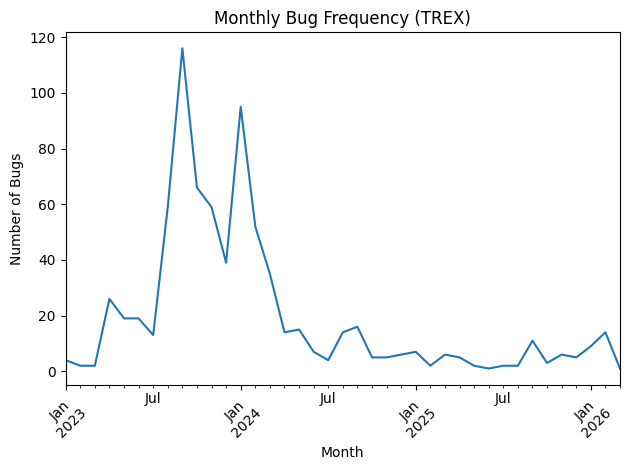

In [77]:
df_full["month"] = df_full["created"].dt.to_period("M")
monthly_trend = df_full.groupby("month").size()

plt.figure()
monthly_trend.plot()
plt.title("Monthly Bug Frequency (TREX)")
plt.xlabel("Month")
plt.ylabel("Number of Bugs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

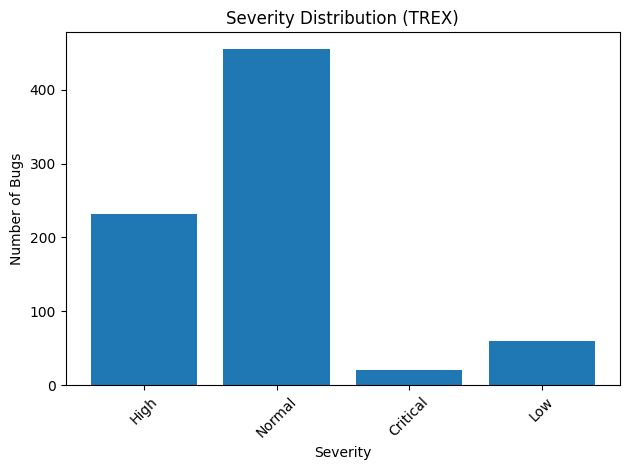

In [78]:
severity_counts = Counter(df_full["priority"])

plt.figure()
plt.bar(severity_counts.keys(), severity_counts.values())
plt.title("Severity Distribution (TREX)")
plt.xlabel("Severity")
plt.ylabel("Number of Bugs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

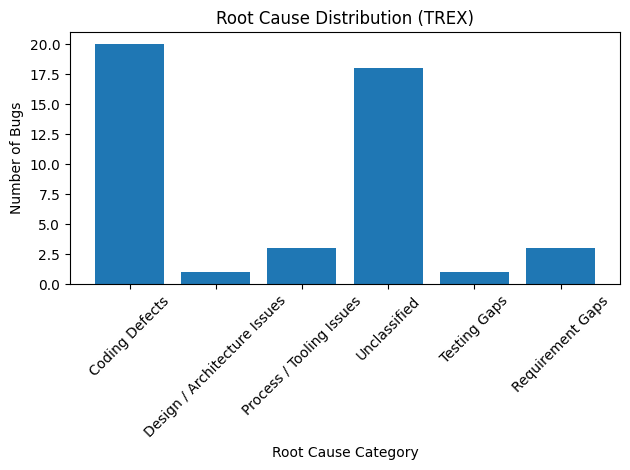

In [79]:
rca_counts = Counter(final_categories)

plt.figure()
plt.bar(rca_counts.keys(), rca_counts.values())
plt.title("Root Cause Distribution (TREX)")
plt.xlabel("Root Cause Category")
plt.ylabel("Number of Bugs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

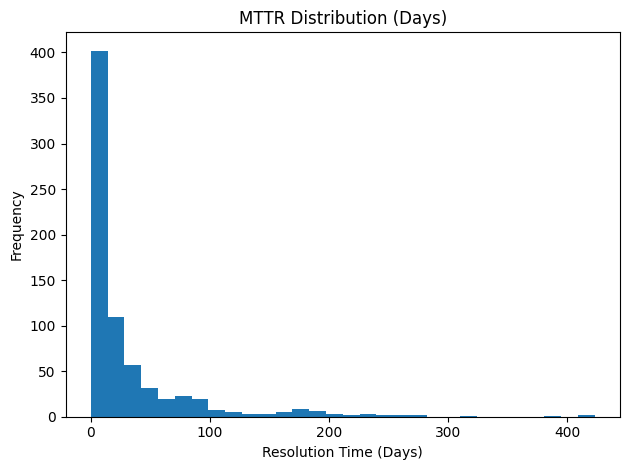

In [80]:
resolved_df = df_full[df_full["resolved"].notna()].copy()
resolved_df["resolution_hours"] = (
    resolved_df["resolved"] - resolved_df["created"]
).dt.total_seconds() / 3600

plt.figure()
plt.hist(resolved_df["resolution_hours"] / 24, bins=30)
plt.title("MTTR Distribution (Days)")
plt.xlabel("Resolution Time (Days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **Observations and recommendations to prevent similar issues in future cycle**s:

**Coding Defects Dominate (43.5%):**

- Nearly half of documented root causes are implementation-related issues.

- Strengthen code quality controls

**Long-Tail Resolution Time (MTTR Skew):**

- Most bugs are resolved quickly in around 10 days, but a subset remains open for extended periods.

